In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [31]:
# data_path = 'dataset.h5'
data_path = 'qtam_try_ampl_cross.h5'
# data_path = 'data/dataset_ae_stft_ampl_cross_200k.h5'
with h5py.File(data_path, 'r') as f:
    print('Attributes:', dict(f.attrs))
    data = f['data'][:]
    params = f['parameters'][:]

print('Data shape:', data.shape)
print('Params shape:', params.shape)

Attributes: {'T_obs': np.float64(648000.0), 'channels': 'AE', 'dt': np.float64(10.0), 'output_format': 'ampl_rel_phase', 'param_names': array(['m1', 'q', 'dist', 't_ref', 'inc', 'lam', 'beta', 'psi', 'phi_ref',
       'chi1', 'chi2'], dtype=object), 'repr_type': 'qtam'}
Data shape: (1333, 4, 64, 1024)
Params shape: (1333, 11)


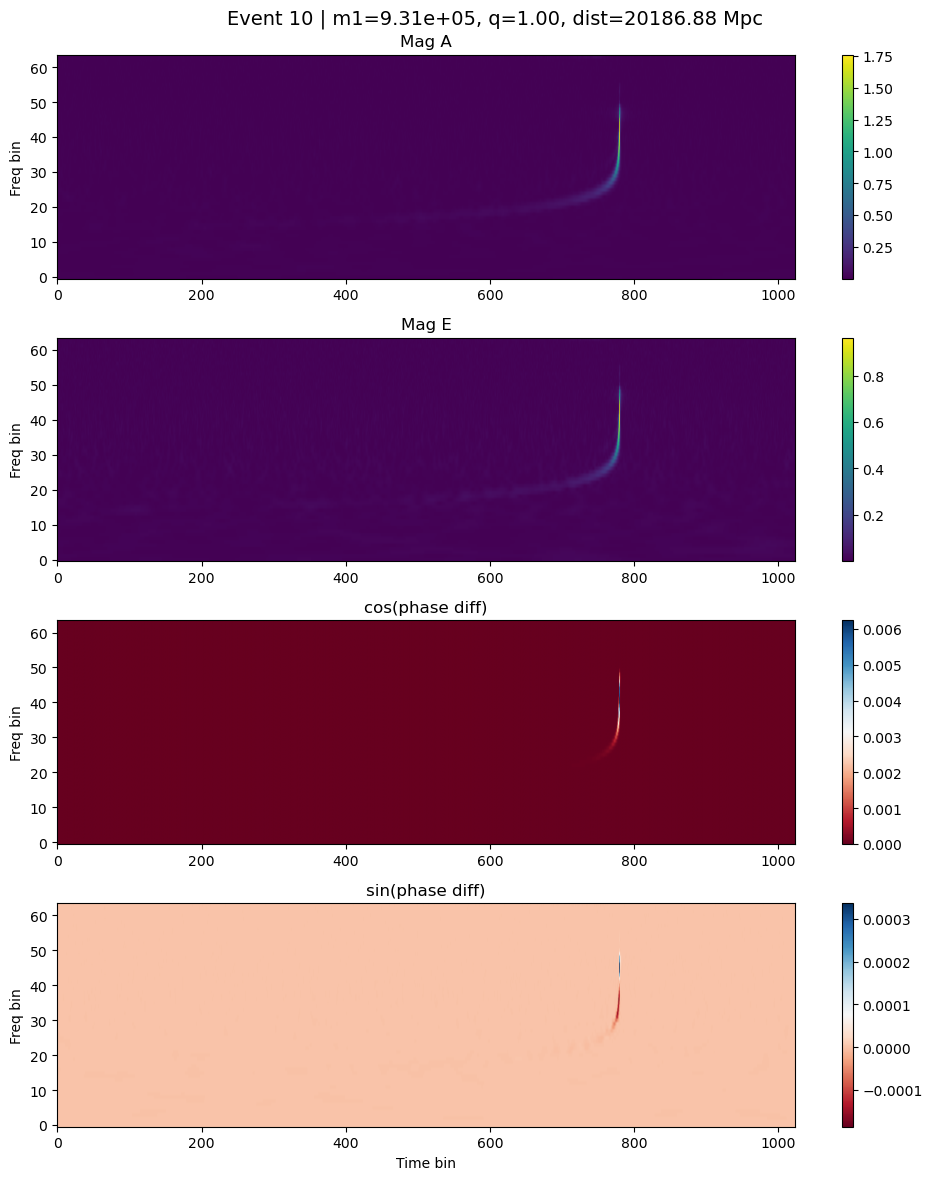

33458


/scratch/users/m/mbellotti/ipykernel_1966709/910270037.py:33: RuntimeWarning: invalid value encountered in log10
  print(np.sum(np.isnan(np.log10(data[10][3]))))


In [43]:
def plot_sample(idx):
    sample_data = data[idx]
    sample_params = params[idx]
    
    fig, axes = plt.subplots(4, 1, figsize=(10, 12))
    
    titles = ['Mag A', 'Mag E', 'cos(phase diff)', 'sin(phase diff)']
    cmaps = ['viridis', 'viridis', 'RdBu', 'RdBu']
    
    for i in range(4):
        ax = axes[i]
        # For log amplitudes, we might want to scale them roughly to visualize better
        img = sample_data[i]
        # im = ax.imshow(np.log10(img), aspect='auto', origin='lower', cmap=cmaps[i])
        im = ax.imshow(img, aspect='auto', origin='lower', cmap=cmaps[i])
        ax.set_title(titles[i])
        ax.set_ylabel('Freq bin')
        fig.colorbar(im, ax=ax)
        
    axes[-1].set_xlabel('Time bin')
    
    # Convert distance parameter from meters back to Mpc
    pc_m = 3.085677581491367e+16
    dist_mpc = sample_params[2] / (1e6 * pc_m)
    
    plt.suptitle(f'Event {idx} | m1={sample_params[0]:.2e}, q={sample_params[1]:.2f}, dist={dist_mpc:.2f} Mpc', fontsize=14)
    plt.tight_layout()
    plt.show()

# Change the index here to view different MBHBs
plot_sample(10)

print(np.sum(np.isnan(np.log10(data[10][3]))))

Global max normalization factor: 51.34385299682617


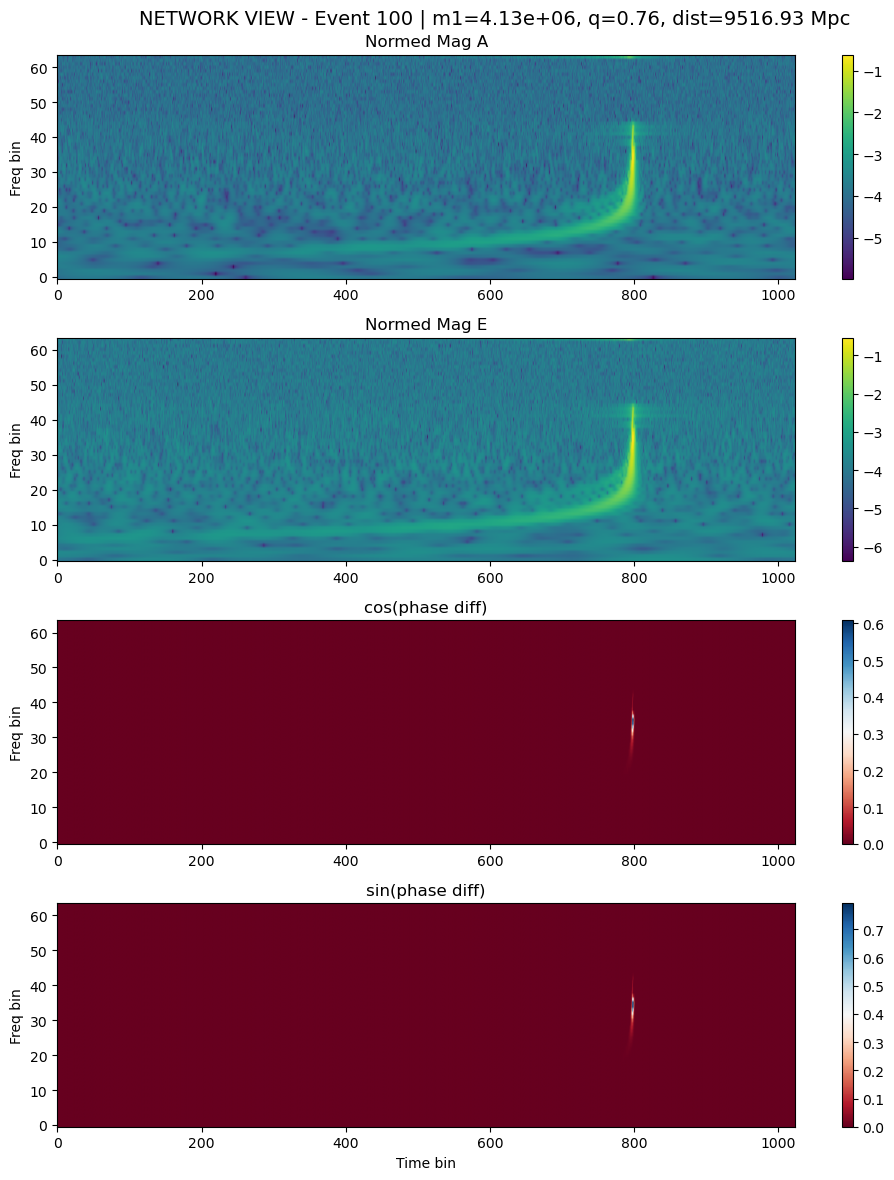

In [51]:
# Calculate the exact normalization that the Dataset class applies
sample_images = data[:min(100, data.shape[0])]
sample_images = np.nan_to_num(sample_images, nan=0.0)
x_max = np.max(np.abs(sample_images[:, :2, :, :]))
print(f"Global max normalization factor: {x_max}")

def plot_network_view(idx):
    # This matches exactly what the __getitem__ method does
    x = data[idx].copy()
    
    # Normalize channels 0 and 1 using the global max!
    x[:2] = x[:2] / x_max
    
    sample_params = params[idx]
    
    fig, axes = plt.subplots(4, 1, figsize=(10, 12))
    
    # We will force the limits of the image to [-1, 1] to properly see
    # how squashed the faint signals get!
    titles = ['Normed Mag A', 'Normed Mag E', 'cos(phase diff)', 'sin(phase diff)']
    cmaps = ['viridis', 'viridis', 'RdBu', 'RdBu']
    
    for i in range(4):
        ax = axes[i]
        img = x[i]
        
        # When plotting magnitude, standard vmin=0, vmax=1 since we divided by max
        if i < 2:
            im = ax.imshow(np.log10(img), aspect='auto', origin='lower', cmap=cmaps[i])
        else:
            im = ax.imshow(img, aspect='auto', origin='lower', cmap=cmaps[i])
            
        ax.set_title(titles[i])
        ax.set_ylabel('Freq bin')
        fig.colorbar(im, ax=ax)
        
    axes[-1].set_xlabel('Time bin')
    
    pc_m = 3.085677581491367e+16
    dist_mpc = sample_params[2] / (1e6 * pc_m)
    
    plt.suptitle(f'NETWORK VIEW - Event {idx} | m1={sample_params[0]:.2e}, q={sample_params[1]:.2f}, dist={dist_mpc:.2f} Mpc', fontsize=14)
    plt.tight_layout()
    plt.show()

# Change the index to 10 like you had above!
plot_network_view(100)